In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number1: int
    number2: int
    op: str
    final: int

In [4]:
def adder(state: AgentState) -> AgentState:
    """this is the adder node of the conditional graph"""

    state['final'] = state['number1'] + state['number2']
    return state


def subtractor(state: AgentState) -> AgentState:
    """this is the subtractor node of the conditional graph"""

    state['final'] = state['number1'] - state['number2']
    return state


def decider(state: AgentState) -> AgentState:
    """this is the decider node of the conditional graph"""

    if state['op'] == '+':
        return "addition_op"
    else:
        return "subtractor_op"


In [5]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder)
graph.add_node("subtractor", subtractor)
graph.add_node("router", lambda state: state) #passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decider,
    {
        "addition_op": "adder",
        "subtractor_op": "subtractor",
    },
)

graph.add_edge("adder", END)
graph.add_edge("subtractor", END)

app = graph.compile()

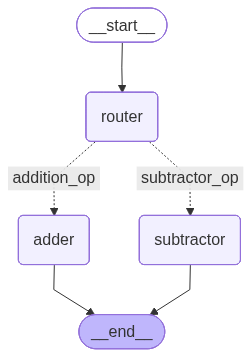

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
result = app.invoke({"number1": 10, "number2": 9, "op": "-"})
print(result)
print(result['final'])

{'number1': 10, 'number2': 9, 'op': '-', 'final': 1}
1


In [17]:
result2 = app.invoke({"number1": 10, "number2": 9, "op": "+"})
print(result2)
print(result2['final'])

{'number1': 10, 'number2': 9, 'op': '+', 'final': 19}
19
